### Exploratory Data Analysis - Speech Commands Dataset.


#### Goal: Understand the dataset before constructing the model.

In [1]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Audio, display

In [2]:
torchaudio.set_audio_backend("soundfile")

C:\Users\Kunal kulkarni\AppData\Local\Temp\ipykernel_19652\1822137616.py:1: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")


#### 1. Download and load the dataset.

In [3]:
DATA_ROOT="../data"
train_set= torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=False, subset="training")
val_set   = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=False, subset="validation")
test_set  = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_ROOT, download=False, subset="testing")

print(f"Train: {len(train_set)} samples.")
print(f"Validation: {len(val_set)} samples.")
print(f"Test: {len(test_set)} samples.")

Train: 84843 samples.
Validation: 9981 samples.
Test: 11005 samples.


#### 2. Exploring a sample

In [4]:
waveform,sample_rate,label,speaker_id,utterance_number=train_set[0]

print(f"Label: {label}.")
print(f"Sample rate: {sample_rate} Hz.")
print(f"Waveform shape: {waveform.shape}.")
print(f"Duration: {(waveform.shape[1] / sample_rate):.3f} sec.")

Label: backward.
Sample rate: 16000 Hz.
Waveform shape: torch.Size([1, 16000]).
Duration: 1.000 sec.


#### 3. Class distribution

In [10]:
speech_commands_path=os.path.join(DATA_ROOT,"SpeechCommands","speech_commands_v0.02")
all_classes=sorted([
    d for d in os.listdir(speech_commands_path)
    if os.path.isdir(os.path.join(speech_commands_path,d))
])
print(f"Total classes found: {len(all_classes)}")
print(all_classes)

Total classes found: 36
['_background_noise_', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [17]:
label_counts = Counter()
for i in range(len(train_set)):
    _, _, lbl, _, _ = train_set[i]
    label_counts[lbl] += 1

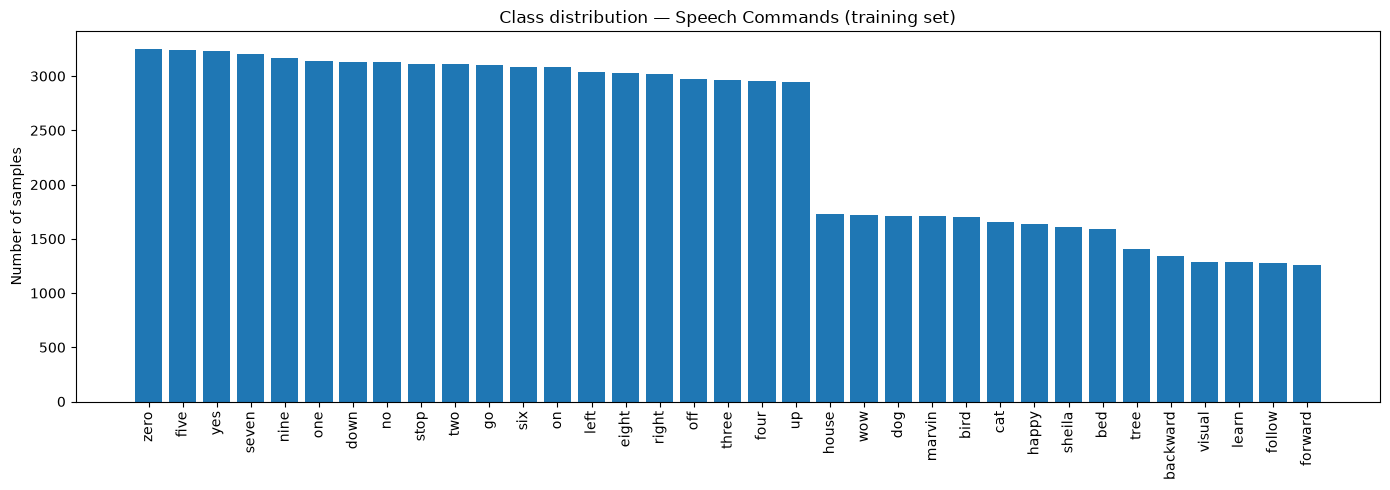

In [18]:
plt.figure(figsize=(14, 5))
labels_sorted = sorted(label_counts.items(), key=lambda x: -x[1])
plt.bar([l for l, _ in labels_sorted], [c for _, c in labels_sorted])
plt.xticks(rotation=90)
plt.ylabel("Number of samples")
plt.title("Class distribution — Speech Commands (training set)")
plt.tight_layout()
plt.show()

#### 4. Check clip durations.

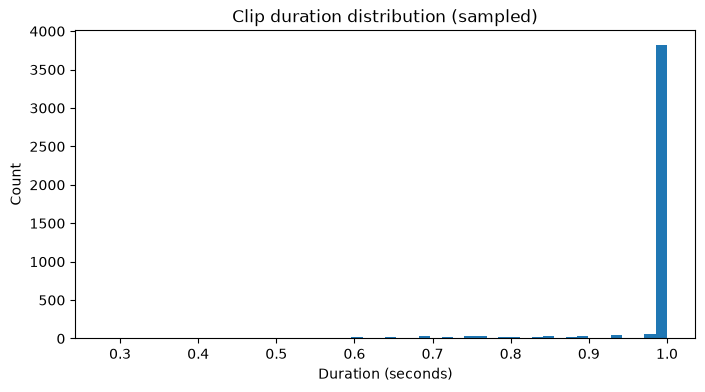

In [5]:
durations=[]
for i in range (0,len(train_set),20):
    wf,sr,_,_,_=train_set[i]
    durations.append(wf.shape[1]/sr)

plt.figure(figsize=(8,4))
plt.hist(durations,bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Clip duration distribution (sampled)")
plt.show()

In [6]:
print(f"Min duration: {min(durations):.3f}s")
print(f"Max duration: {max(durations):.3f}s")
print(f"Most common duration: {Counter (durations).most_common(1)}")

Min duration: 0.279s
Max duration: 1.000s
Most common duration: [(1.0, 3818)]


#### 5. Listen to a few samples

In [26]:
wf,sr,lbl,_,_=train_set[4]
print(f"Label: {lbl}")
display(Audio(wf.numpy(),rate=sr))

wf,sr,lbl,_,_=train_set[7959]
print(f"Label: {lbl}")
display(Audio(wf.numpy(),rate=sr))

wf,sr,lbl,_,_=train_set[5000]
print(f"Label: {lbl}")
display(Audio(wf.numpy(),rate=sr))

wf,sr,lbl,_,_=train_set[4544]
print(f"Label: {lbl}")
display(Audio(wf.numpy(),rate=sr))

Label: backward


Label: dog


Label: cat


Label: bird


#### 6. Visualize a raw waveform. 

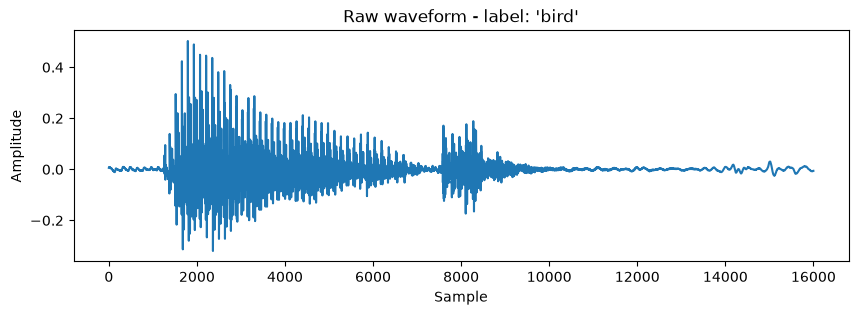

In [27]:
wf,sr,lbl,_,_=train_set[4544]

plt.figure(figsize=(10,3))
plt.plot(wf[0].numpy())
plt.title(f"Raw waveform - label: '{lbl}'")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

#### 7. Visualize mel-spectrograms for a few different words 

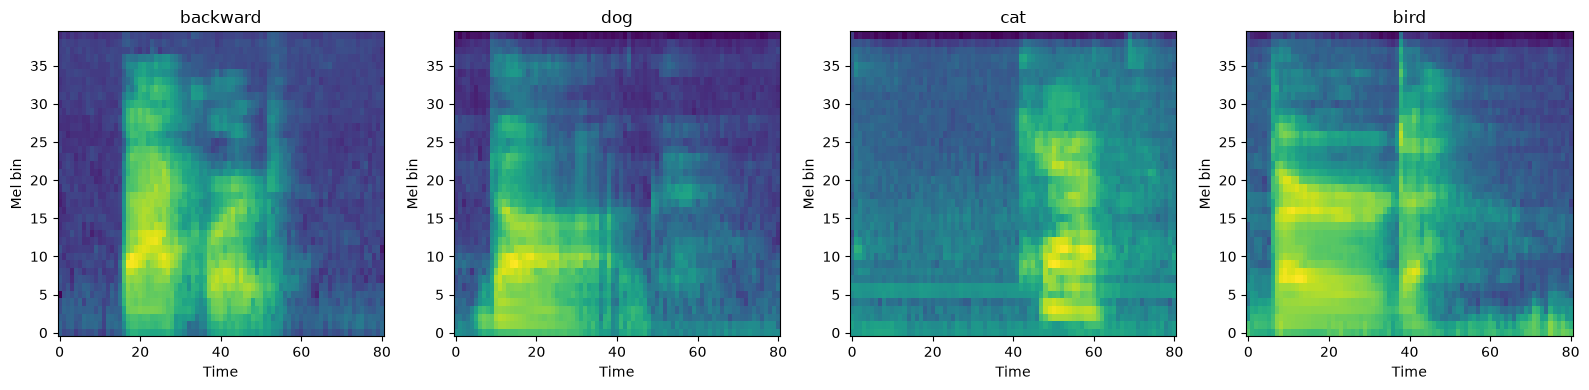

In [ ]:

word_indices = {
    "backward": 4,
    "dog": 7959,
    "cat": 5000,
    "bird": 4544,
}

mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_mels=40)

fig, axes = plt.subplots(1, len(word_indices), figsize=(16, 4))

for ax, (word, i) in zip(axes, word_indices.items()):
    wf, sr, lbl, _, _ = train_set[i]
    mel_spec = mel_transform(wf)
    mel_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)
    ax.imshow(mel_db[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(word)
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.tight_layout()
plt.show()

Alternatively you may use the below snippet to loop through data set with your own keywords. I had to use the above one as the one below was too slow on my device.

In [ ]:
#words_to_check=[]

# mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_mels=40)
 
# fig, axes = plt.subplots(1, len(words_to_check), figsize=(16, 4))
 
# for ax, word in zip(axes, words_to_check):
#     for i in range(len(train_set)):
#         wf, sr, lbl, _, _ = train_set[i]
#         if lbl == word:
#             mel_spec = mel_transform(wf)
#             mel_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)
#             ax.imshow(mel_db[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
#             ax.set_title(word)
#             ax.set_xlabel("Time")
#             ax.set_ylabel("Mel bin")
#             break
 
# plt.tight_layout()
# plt.show()